Copying files: 4127 files [00:15, 273.22 files/s]


Found 3301 images belonging to 2 classes.
Found 412 images belonging to 2 classes.
Found 414 images belonging to 2 classes.
Class weights: {0: 1.0315625, 1: 0.9703115814226926}
Found 3301 images belonging to 2 classes.


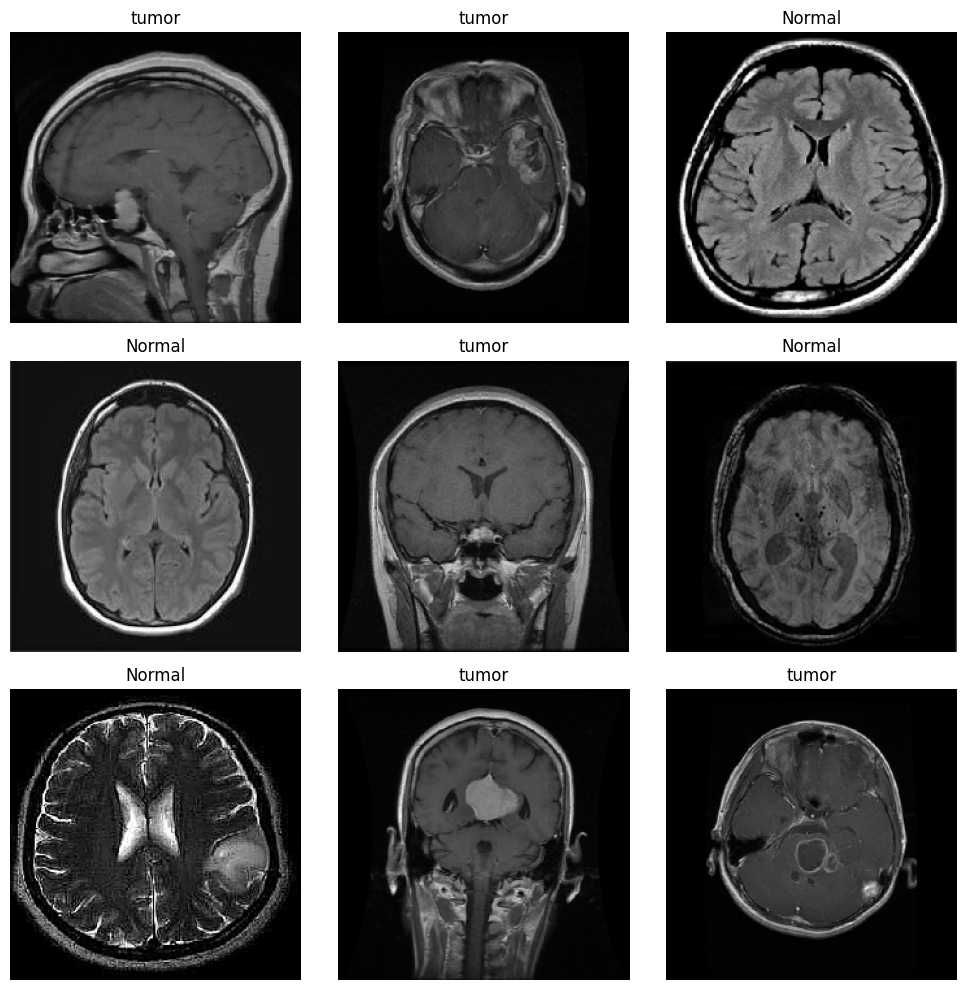

notumor: 1600 images
tumor: 1701 images
Shape of batch X: (32, 224, 224, 3)


In [3]:
import os
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

input_folder = r"C:\tumordata"
output_folder = r"C:\tumordata_split"

if not os.path.exists(output_folder):
    splitfolders.ratio(
        input_folder,
        output=output_folder,
        seed=42,
        ratio=(0.8, 0.1, 0.1)
    )

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

y = train_data.classes.astype(int)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

vis_datagen = ImageDataGenerator(rescale=1./255)
vis_data = vis_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=9,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True
)

x_vis, y_vis = next(vis_data)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_vis[i])
    plt.title("tumor" if y_vis[i]==1 else "Normal")
    plt.axis("off")
plt.tight_layout()
plt.show()

for cls, idx in train_data.class_indices.items():
    count = len(os.listdir(os.path.join(train_data.directory, cls)))
    print(f"{cls}: {count} images")

x_batch, y_batch = next(train_data)
print("Shape of batch X:", x_batch.shape)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = (224, 224, 3)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))

# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,               # You can increase epochs as needed
    class_weight=class_weight_dict,
    verbose=1
)


NameError: name 'compute_class_weight' is not defined

In [2]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

C:\Users\Vishva\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 621ms/step


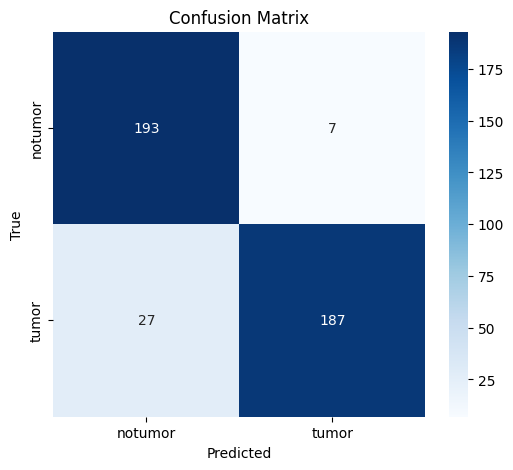


Classification Report:

              precision    recall  f1-score   support

     notumor       0.88      0.96      0.92       200
       tumor       0.96      0.87      0.92       214

    accuracy                           0.92       414
   macro avg       0.92      0.92      0.92       414
weighted avg       0.92      0.92      0.92       414



In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# True labels
y_true = test_data.classes

# Predicted probabilities
y_pred_probs = model.predict(test_data)  # shape: (num_samples, 1)

# Convert probabilities to class labels
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # 0 or 1

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

In [11]:
 model.save('Tumor.h5')